# Flight Risk - Model Comparison

This notebook evaluates the performance of a machine learning model for predicting flight delays.

To ensure a fair comparison, all experiments use:

- The same feature-engineered dataset
- The same binary target (is_delayed)
- The same temporal train/validation/test split
- The same evaluation metrics

The only component that changes between notebooks is the learning algorithm.

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Utilities
import joblib

In [2]:
# Plot Style

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Load Dataset

In [3]:
df = pd.read_parquet("../.data/flights_features.parquet")

print(f"Dataset shape: {df.shape}")

display(df.head())

Dataset shape: (2964978, 56)


,airline_icao,origin_icao,destination_icao,dep_scheduled,origin_elevation_ft,origin_region,destination_elevation_ft,destination_region,origin_wx_temperature_2m,origin_wx_precipitation,origin_wx_windspeed_10m,origin_wx_windgusts_10m,origin_wx_cloudcover,origin_wx_surface_pressure,destination_wx_temperature_2m,destination_wx_precipitation,destination_wx_windspeed_10m,destination_wx_windgusts_10m,destination_wx_cloudcover,destination_wx_surface_pressure,dep_day_of_year,dep_is_weekend,dep_hour_sin,dep_hour_cos,dep_dow_sin,dep_dow_cos,dep_month_sin,dep_month_cos,dep_time_block,dep_is_peak_hour,dep_is_holiday,route,region_pair,distance_km,flight_range,elevation_diff_ft,origin_airport_size,destination_airport_size,is_trunk_route,origin_hourly_flights,destination_hourly_arrivals,total_hourly_congestion,origin_wx_condition,destination_wx_condition,origin_wx_is_fog,origin_wx_is_rain,origin_wx_is_storm,destination_wx_is_fog,destination_wx_is_rain,destination_wx_is_storm,route_hist_delay_mean,route_hist_delay_std,route_hist_delay_rate,airline_hour_delay_rate,airline_hour_delay_mean,is_delayed
0,TAM,SBRJ,SBGR,2022-01-06 14:20:00,11.000,BR-RJ,2461.000,BR-SP,29.081,0.000,10.740,27.720,92.000,1005.459,22.600,5.400,17.874,34.560,98.000,926.656,6,0,-0.500,-0.866,0.434,-0.901,0.500,0.866,afternoon,0,0,SBRJ_SBGR,BR-RJ_BR-SP,342.990,short,2450.000,3.000,3.000,1,5,14,19,cloudy,rain,0,0,0,0,1,0,4.499,21.866,0.157,0.163,5.628,0
1,TAM,SBRJ,SBGR,2022-01-07 14:20:00,11.000,BR-RJ,2461.000,BR-SP,24.531,0.500,20.874,49.680,100.000,1009.652,21.400,1.500,20.618,39.600,100.000,929.092,7,0,-0.500,-0.866,-0.434,-0.901,0.500,0.866,afternoon,0,0,SBRJ_SBGR,BR-RJ_BR-SP,342.990,short,2450.000,3.000,3.000,1,6,12,18,rain,rain,0,1,0,0,1,0,4.499,21.866,0.157,0.163,5.628,1
2,TAM,SBRJ,SBGR,2022-01-08 14:20:00,11.000,BR-RJ,2461.000,BR-SP,23.881,0.600,13.896,34.560,100.000,1011.151,20.000,0.200,22.907,44.280,100.000,929.817,8,1,-0.500,-0.866,-0.975,-0.223,0.500,0.866,afternoon,0,0,SBRJ_SBGR,BR-RJ_BR-SP,342.990,short,2450.000,3.000,3.000,1,5,11,16,rain,rain,0,1,0,0,1,0,4.499,21.866,0.157,0.163,5.628,0
3,TAM,SBRJ,SBGR,2022-01-09 14:20:00,11.000,BR-RJ,2461.000,BR-SP,24.281,0.400,3.827,14.760,100.000,1013.351,20.100,0.100,21.383,38.520,100.000,930.395,9,1,-0.500,-0.866,-0.782,0.623,0.500,0.866,afternoon,0,0,SBRJ_SBGR,BR-RJ_BR-SP,342.990,short,2450.000,3.000,3.000,1,9,14,23,rain,rain,0,1,0,0,1,0,4.499,21.866,0.157,0.163,5.628,0
4,TAM,SBRJ,SBGR,2022-01-11 14:20:00,11.000,BR-RJ,2461.000,BR-SP,25.631,0.000,11.183,26.280,100.000,1008.754,25.200,0.000,4.350,16.200,100.000,927.982,11,0,-0.500,-0.866,0.782,0.623,0.500,0.866,afternoon,0,0,SBRJ_SBGR,BR-RJ_BR-SP,342.990,short,2450.000,3.000,3.000,1,7,10,17,cloudy,cloudy,0,0,0,0,0,0,4.499,21.866,0.157,0.163,5.628,0


In [4]:
# Dataset Overview

print("=" * 40)
print("DATASET OVERVIEW")
print("=" * 40)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nMissing values (Top 10):")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("\nTarget distribution:")
display(df["is_delayed"].value_counts())

print("\nTarget distribution (%):")
display(
    df["is_delayed"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

DATASET OVERVIEW
Rows: 2,964,978
Columns: 56

Missing values (Top 10):


route_hist_delay_std        166
origin_airport_size          42
destination_airport_size     42
airline_icao                  0
total_hourly_congestion       0
dep_is_holiday                0
route                         0
region_pair                   0
distance_km                   0
flight_range                  0
dtype: int64


Target distribution:


is_delayed
0    2522268
1     442710
Name: count, dtype: int64


Target distribution (%):


is_delayed
0   85.070
1   14.930
Name: proportion, dtype: float64

In [9]:
# Define Features and Target

TARGET = "is_delayed"
METADATA = ["dep_scheduled"]

X = df.drop(columns=[TARGET] + METADATA)
y = df[TARGET]

print("=" * 40)
print("FEATURES AND TARGET")
print("=" * 40)

print(f"Features: {X.shape[1]}")
print(f"Target: {TARGET}")

FEATURES AND TARGET
Features: 54
Target: is_delayed


In [10]:
# Temporal Train / Validation / Test Split

VAL_CUTOFF = "2025-07-01"

dates = df["dep_scheduled"]

train_mask = dates.dt.year.isin([2022, 2023, 2024])
val_mask = (~train_mask) & (dates < VAL_CUTOFF)
test_mask = (~train_mask) & (dates >= VAL_CUTOFF)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("=" * 40)
print("TEMPORAL SPLIT")
print("=" * 40)

print(f"Train:      {len(X_train):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")

TEMPORAL SPLIT
Train:      2,193,914 rows
Validation: 379,819 rows
Test:       391,245 rows


In [11]:
# Target Distribution by Split

split_distribution = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
    "Validation (%)": y_val.value_counts(normalize=True).sort_index().mul(100).round(2),
    "Test (%)": y_test.value_counts(normalize=True).sort_index().mul(100).round(2),
})

display(split_distribution)

,Train (%),Validation (%),Test (%)
is_delayed,,,
0,85.050,86.390,83.920
1,14.950,13.610,16.080


In [12]:
# Identify Categorical Features

cat_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("=" * 40)
print("CATEGORICAL FEATURES")
print("=" * 40)

print(f"Number of categorical features: {len(cat_features)}\n")

for col in cat_features:
    print(f"• {col}")

CATEGORICAL FEATURES
Number of categorical features: 11

• airline_icao
• origin_icao
• destination_icao
• origin_region
• destination_region
• dep_time_block
• route
• region_pair
• flight_range
• origin_wx_condition
• destination_wx_condition


In [16]:
# Train CatBoost Model

catboost_model_balanced = CatBoostClassifier(
    iterations=700,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=80
)

catboost_model_balanced.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	test: 0.6066456	best: 0.6066456 (0)	total: 1.58s	remaining: 18m 22s
100:	test: 0.6391312	best: 0.6392272 (99)	total: 2m 1s	remaining: 11m 59s
200:	test: 0.6455882	best: 0.6455882 (200)	total: 4m 1s	remaining: 10m
300:	test: 0.6482201	best: 0.6482588 (297)	total: 6m 3s	remaining: 8m 1s
400:	test: 0.6494844	best: 0.6495261 (393)	total: 8m 45s	remaining: 6m 31s
500:	test: 0.6496310	best: 0.6497761 (493)	total: 11m 6s	remaining: 4m 24s
600:	test: 0.6496125	best: 0.6497853 (554)	total: 13m 2s	remaining: 2m 8s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.6497852778
bestIteration = 554

Shrink model to first 555 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=80, eval_metric='AUC', iterations=700, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [14]:
# Validation Predictions

y_val_pred = catboost_model.predict(X_val)
y_val_proba = catboost_model.predict_proba(X_val)[:, 1]

print("=" * 40)
print("VALIDATION PREDICTIONS")
print("=" * 40)
print("Predictions generated successfully.")

VALIDATION PREDICTIONS
Predictions generated successfully.


In [15]:
# Validation Metrics

print("=" * 40)
print("VALIDATION METRICS - CATBOOST")
print("=" * 40)

print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=3))

VALIDATION METRICS - CATBOOST
Accuracy:  0.8635
Precision: 0.3560
Recall:    0.0030
F1-score:  0.0060
ROC-AUC:   0.6484

Classification Report:
              precision    recall  f1-score   support

           0      0.864     0.999     0.927    328118
           1      0.356     0.003     0.006     51701

    accuracy                          0.864    379819
   macro avg      0.610     0.501     0.466    379819
weighted avg      0.795     0.864     0.801    379819



In [17]:
y_val_pred_balanced = catboost_model_balanced.predict(X_val)
y_val_proba_balanced = catboost_model_balanced.predict_proba(X_val)[:, 1]

print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_balanced):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_balanced):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_balanced):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred_balanced):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_proba_balanced):.4f}")

print(classification_report(y_val, y_val_pred_balanced, digits=3))

Accuracy:  0.6836
Precision: 0.2101
Recall:    0.4801
F1-score:  0.2923
ROC-AUC:   0.6498
              precision    recall  f1-score   support

           0      0.897     0.716     0.796    328118
           1      0.210     0.480     0.292     51701

    accuracy                          0.684    379819
   macro avg      0.554     0.598     0.544    379819
weighted avg      0.804     0.684     0.728    379819



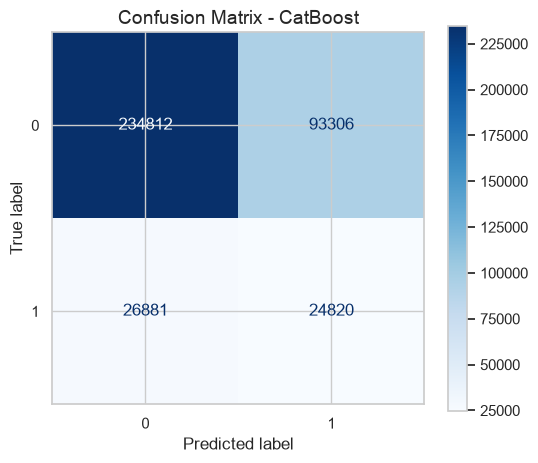

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_balanced,
    ax=ax,
    cmap="Blues"
)

plt.title("Confusion Matrix - CatBoost")
plt.show()

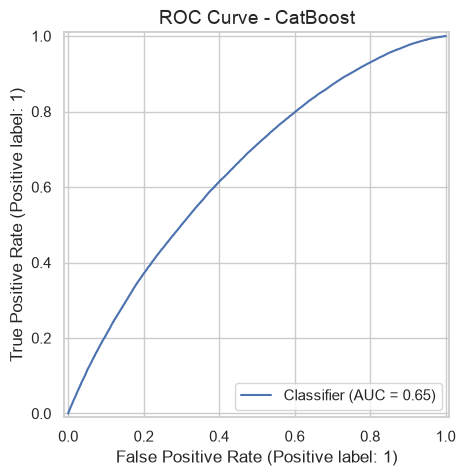

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba_balanced,
    ax=ax
)

plt.title("ROC Curve - CatBoost")
plt.show()

# Conclusion

The primary evaluation metric adopted in this project is ROC-AUC, as it provides a threshold-independent measure of the model's ability to distinguish delayed from non-delayed flights and is well suited for this moderately imbalanced classification problem.

The CatBoost model achieved a ROC-AUC of approximately **0.650** on the validation set, showing a modest improvement over the Logistic Regression baseline.

The results obtained in this notebook contribute to the comparative evaluation of candidate models and will be considered alongside the other models developed in the project for the final model selection.